In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

In [2]:
with open("/workspace/deception-detection/results/by_layer_harm_pressure_choice_control_10000_lr__repe_honesty__plain__llama-70b-3.3__20260108_164517/scores_by_layer.json", "r") as f:
    scores = json.load(f)
    
print(scores.keys())

dict_keys(['repe_honesty__plain_val', 'harm_pressure_choice__test', 'alpaca__plain'])


In [3]:
all_layers_control_scores = []
all_layers_hp_scores = []
for layer in tqdm(range(80)):
    control_scores = scores["alpaca__plain"][str(layer)]
    hp_scores = scores["harm_pressure_choice__test"][str(layer)]
    
    promptwise_control_scores = [np.mean(control_score) for control_score in control_scores["scores"]]
    hp_scores_all = hp_scores["scores"]
    hp_labels_all = hp_scores["labels"]
    promptwise_hp_scores = []
    for i, label in enumerate(hp_labels_all):
        promptwise_hp_scores.append(np.mean(hp_scores_all[i]))
            
    all_layers_control_scores.append(promptwise_control_scores)
    all_layers_hp_scores.append(promptwise_hp_scores)

100%|██████████| 80/80 [00:06<00:00, 12.65it/s]


In [4]:
len(all_layers_control_scores), len(all_layers_hp_scores)

(80, 80)

In [5]:
def auroc(scores, labels):
    return roc_auc_score(labels, scores)

def tpr_at_1pct_fpr(preds, labels):
    tp = sum((p == 1 and l == 1) for p, l in zip(preds, labels))
    fn = sum((p == 0 and l == 1) for p, l in zip(preds, labels))

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return recall
    

In [6]:
def get_results(
    ls_1,
    ls_2,
    ls_3,
    ls_4,
    labels,
    i,
    j,
    output_dir
):
    
    ls_1 = np.array(ls_1)
    ls_2 = np.array(ls_2)
    ls_3 = np.array(ls_3)
    ls_4 = np.array(ls_4)
    y = np.array(labels)
    
    def ensemble_scores(w):
        scores = w*ls_2 + (1-w)*ls_4
        return scores, y
    
    ## Optimize AUROC
    ws = np.linspace(0, 1, 201)
    aurocs = []
    
    for w in ws:
        scores, labels = ensemble_scores(w)
        aurocs.append(auroc(scores, labels))
    
    best_w_auroc = ws[np.argmax(aurocs)]
    best_auroc = max(aurocs)
    
    def ensemble_scores_control(w):
        control_scores = w*ls_1 + (1-w)*ls_3
        scores = w*ls_2 + (1-w)*ls_4
        thresh = np.percentile(control_scores, 99)
        preds = (scores >= thresh).astype(int)
        return preds, y
    
    ## Optimize TPR
    tprs = []
    
    for w in ws:
        preds, labels = ensemble_scores_control(w)
        tprs.append(tpr_at_1pct_fpr(preds, labels))
        
    best_w_tpr = ws[np.argmax(tprs)]
    best_tpr = max(tprs)
    
    if i >= j:
        plt.figure(figsize=(7, 4))
        plt.plot(ws, aurocs, label="AUROC")
        plt.plot(ws, tprs, label="TPR @ 1% FPR")
        plt.axvline(best_w_auroc, linestyle="--", alpha=0.5)
        plt.axvline(best_w_tpr, linestyle="--", alpha=0.5, color="orange")
        plt.xlabel("Ensemble weight w (Classifier A)")
        plt.ylabel("Metric value")
        plt.legend()
        plt.title("Ensemble performance vs weighting")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"ensemble_performance_layer_{i}_and_{j}.png"))
        plt.close()
    
    return best_auroc, best_tpr 

In [ ]:
output_dir = "/workspace/deception-detection/results/soft_ensembling_results_harm_pressure_choice_actual_auroc"
os.makedirs(output_dir, exist_ok=True)
probe_layers = list(range(1,10)) + list(range(25, 40)) + list(range(70, 80))
best_auroc_ls = [[] for _ in range(len(probe_layers))]
best_tpr_ls = [[] for _ in range(len(probe_layers))]
for idx, i in enumerate(probe_layers):
    for j in tqdm(probe_layers):  
        best_auroc, best_tpr = get_results(
            all_layers_control_scores[i],
            all_layers_hp_scores[i],
            all_layers_control_scores[j],
            all_layers_hp_scores[j],
            [1 if hp_labels_all[k] == "DECEPTIVE" else 0 for k in range(len(hp_labels_all))],
            i,
            j,
            output_dir
        )
        
        best_auroc_ls[idx].append(best_auroc)
        best_tpr_ls[idx].append(best_tpr)
        

  6%|▌         | 2/34 [00:01<00:29,  1.09it/s]

In [ ]:
best_auroc_all_single_probe_ls = []
best_tpr_all_single_probe_ls = []
for i in range(80):
    layer_control_scores = all_layers_control_scores[i]
    layer_hp_scores = all_layers_hp_scores[i]
    y = [1 if hp_labels_all[k] == "DECEPTIVE" else 0 for k in range(len(hp_labels_all))]
    best_auroc_all_single_probe_ls.append(auroc(layer_hp_scores, y))
    control_threshold = np.percentile(layer_control_scores, 99)
    hp_predictions_all = (layer_hp_scores >= control_threshold).astype(int)
    best_tpr_all_single_probe_ls.append(tpr_at_1pct_fpr(hp_predictions_all, y))

In [ ]:
best_auroc = np.max(np.array(best_auroc_all_single_probe_ls))
best_auroc_layer = np.argmax(np.array(best_auroc_all_single_probe_ls))
best_tpr_corresponding = best_tpr_all_single_probe_ls[best_auroc_layer]
print(f"Best single probe AUROC: {best_auroc} at layer {best_auroc_layer} with TPR: {best_tpr_corresponding}")

best_tpr = np.max(np.array(best_tpr_all_single_probe_ls[1:]))
best_tpr_layer = np.argmax(np.array(best_tpr_all_single_probe_ls[1:])) + 1
best_auroc_corresponding = best_auroc_all_single_probe_ls[best_tpr_layer]
print(f"Best single probe TPR: {best_tpr} at layer {best_tpr_layer} with AUROC: {best_auroc_corresponding}")

Best single probe AUROC: 0.8822740582878633 at layer 76 with TPR: 0.26884779516358465
Best single probe TPR: 0.5049786628733998 at layer 3 with AUROC: 0.3807863195266129


In [ ]:
diff_best_auroc_ls = [[] for _ in range(len(probe_layers))]
diff_best_tpr_ls = [[] for _ in range(len(probe_layers))]
for i in range(len(probe_layers)):
    for j in range(len(probe_layers)):
        diff_best_auroc = best_auroc_ls[i][j] - best_auroc
        diff_best_tpr = best_tpr_ls[i][j] - best_tpr_corresponding
        diff_best_auroc_ls[i].append(diff_best_auroc)
        diff_best_tpr_ls[i].append(diff_best_tpr)
            

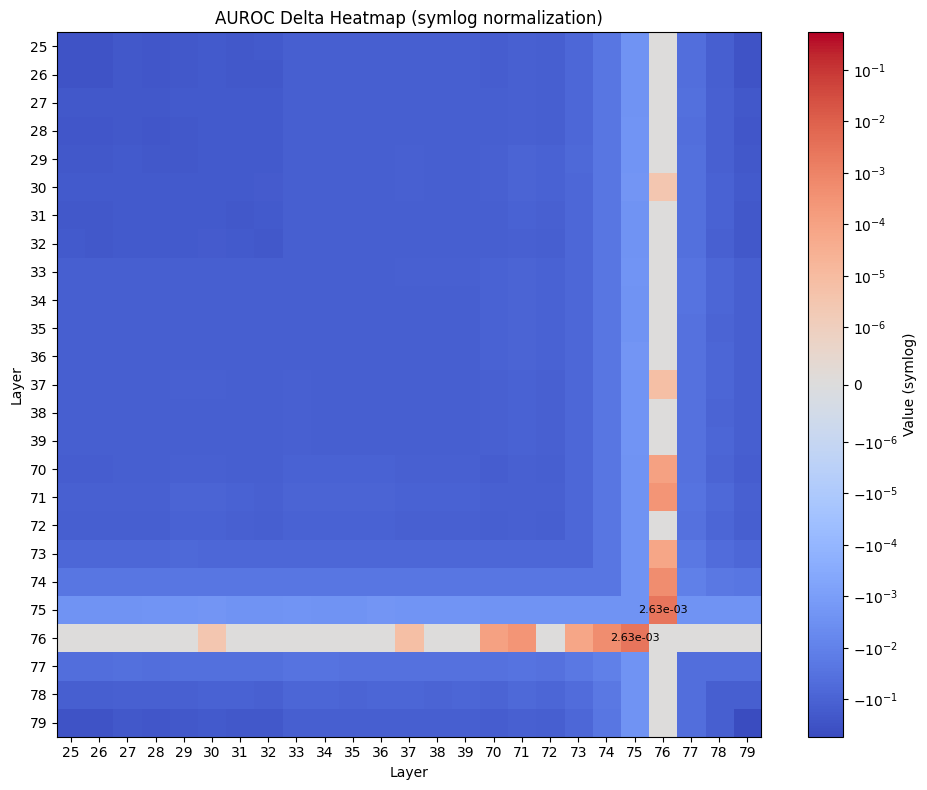

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

data = np.array(diff_best_auroc_ls)
v = np.max(np.abs(data))

layers = probe_layers  # 25, 26, ..., 39

plt.figure(figsize=(10, 8))
im = plt.imshow(
    data,
    cmap="coolwarm",
    norm=SymLogNorm(
        linthresh=1e-6,
        vmin=-v,
        vmax=v
    )
)

plt.colorbar(im, label="Value (symlog)")

# --- Axis ticks and labels ---
plt.xticks(ticks=np.arange(len(layers)), labels=layers)
plt.yticks(ticks=np.arange(len(layers)), labels=layers)

plt.xlabel("Layer")
plt.ylabel("Layer")
plt.title("AUROC Delta Heatmap (symlog normalization)")

threshold = 1e-3  # 10e-4 = 1e-3, but assuming you meant 1e-4

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if (val) >= threshold:
            plt.text(
                j, i,
                f"{val:.2e}",
                ha="center",
                va="center",
                fontsize=5,
                color="black" if abs(val) < 0.5 * v else "white"
            )

plt.tight_layout()
plt.show()


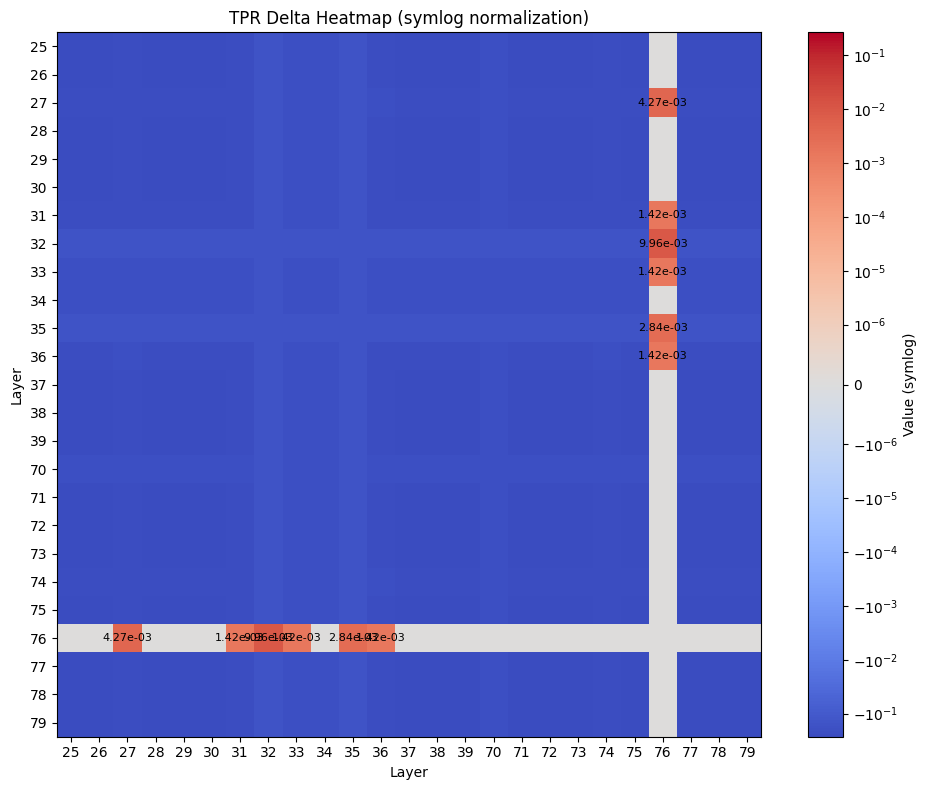

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

data = np.array(diff_best_tpr_ls)
v = np.max(np.abs(data))

layers = probe_layers  # 25, 26, ..., 39

plt.figure(figsize=(10, 8))
im = plt.imshow(
    data,
    cmap="coolwarm",
    norm=SymLogNorm(
        linthresh=1e-6,
        vmin=-v,
        vmax=v
    )
)

plt.colorbar(im, label="Value (symlog)")

# --- Axis ticks and labels ---
plt.xticks(ticks=np.arange(len(layers)), labels=layers)
plt.yticks(ticks=np.arange(len(layers)), labels=layers)

plt.xlabel("Layer")
plt.ylabel("Layer")
plt.title("TPR Delta Heatmap (symlog normalization)")

# --- Write values only above threshold ---
threshold = 1e-3  # change to 1e-3 if you literally want 10e-4

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if (val) >= threshold:
            plt.text(
                j, i,
                f"{val:.2e}",
                ha="center",
                va="center",
                fontsize=5,
                color="black" if abs(val) < 0.5 * v else "white"
            )

plt.tight_layout()
plt.show()
